In [1]:
import matplotlib.pyplot as plt
sys.path.append('../../../AMAZE_model_selection/')
from populations.bbh_models import *
sys.path.append('../')
from plot_functions import make_pop_corner

%matplotlib inline

/data/wiay/2297403c/conda_envs/amaze/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


plotting samples


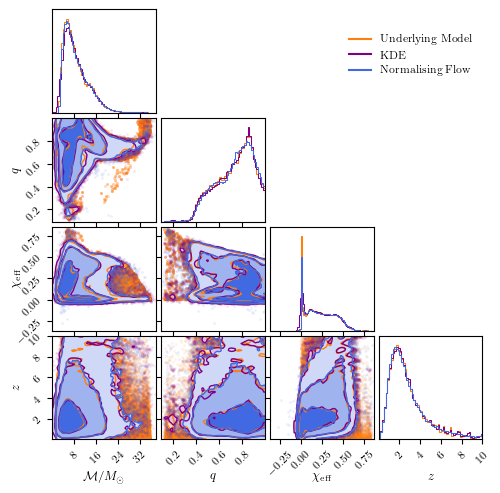

In [10]:
hyperparam_idxs = [0,3]
fig, flow_samps, kde_samps = make_pop_corner('CE', hyperparam_idxs, justplot=True, flow_dir=None, conditional=None,\
    outdir='/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/plots/prod_091224', plot_KDE=True, testCE=False)


In [3]:
#get training population samples
_models_path ='/data/wiay/2297403c/models_reduced.hdf5'
_params = ['mchirp','q', 'chieff', 'z']
channel_label='CE'

popsynth_outputs = read_hdf5(_models_path, channel_label) # read all data from hdf5 file
models_dict = dict.fromkeys(popsynth_outputs.keys())
weights_dict = dict.fromkeys(popsynth_outputs.keys())

for key in popsynth_outputs.keys():
    models_dict[key] = popsynth_outputs[key][_params]
    weights_dict[key]= popsynth_outputs[key]['weight']

In [4]:
from matplotlib.transforms import (Bbox, TransformedBbox,
                                   blended_transform_factory)
from mpl_toolkits.axes_grid1.inset_locator import (BboxConnector,
                                                   BboxConnectorPatch,
                                                   BboxPatch)

In [5]:
def connect_bbox(bbox1, bbox2,
                 loc1a, loc2a, loc1b, loc2b,
                 prop_lines, prop_patches=None):
    if prop_patches is None:
        prop_patches = {
            **prop_lines,
            "alpha": prop_lines.get("alpha", 1) * 0.2,
            "clip_on": False,
        }

    c1 = BboxConnector(
        bbox1, bbox2, loc1=loc1a, loc2=loc2a, clip_on=False, **prop_lines)
    c2 = BboxConnector(
        bbox1, bbox2, loc1=loc1b, loc2=loc2b, clip_on=False, **prop_lines)

    bbox_patch1 = BboxPatch(bbox1, **prop_patches)
    bbox_patch2 = BboxPatch(bbox2, **prop_patches)

    p = BboxConnectorPatch(bbox1, bbox2,
                           loc1a=loc1a, loc2a=loc2a, loc1b=loc1b, loc2b=loc2b,
                           clip_on=False,
                           **prop_patches)

    return c1, c2, bbox_patch1, bbox_patch2, p
def zoom_effect02(ax1, ax2, **kwargs):
    """
    ax1 : the main Axes
    ax1 : the zoomed Axes

    Similar to zoom_effect01.  The xmin & xmax will be taken from the
    ax1.viewLim.
    """

    tt = ax1.transScale + (ax1.transLimits + ax2.transAxes)
    trans = blended_transform_factory(ax2.transData, tt)

    mybbox1 = ax1.bbox
    mybbox2 = TransformedBbox(ax1.viewLim, trans)

    prop_patches = {**kwargs, "ec": "none", "alpha": 0.0}

    c1, c2, bbox_patch1, bbox_patch2, p = connect_bbox(
        mybbox1, mybbox2,
        loc1a=3, loc2a=2, loc1b=4, loc2b=1,
        prop_lines=kwargs, prop_patches=prop_patches)

    ax1.add_patch(bbox_patch1)
    ax2.add_patch(bbox_patch2)
    ax2.add_patch(c1)
    ax2.add_patch(c2)
    ax2.add_patch(p)

    return c1, c2, bbox_patch1, bbox_patch2, p

In [9]:
pt = 1./72.27
jour_sizes = {"AAS": {"onecol": 242.26653*pt, "twocol": 242.26653*2*pt},
              # Add more journals below. Can add more properties to each journal
             }
figure_width = jour_sizes["AAS"]["onecol"]
colors=['C1', 'purple', 'royalblue']

inset = fig.add_subplot(444)
ll, bb, ww, hh =inset.get_position().bounds
inset.set_position([ll-0.2*ww, bb - 0.75*hh, ww, hh])

inset.hist(flow_samps[:,2], density=True,linewidth=.75,bins=300, color=colors[2], histtype='step')
inset.hist(kde_samps[:,2], density=True,linewidth=.75,bins=300, color=colors[1], histtype='step')
inset.hist(models_dict[tuple(hyperparam_idxs)]['chieff'], weights=weights_dict[tuple(hyperparam_idxs)],density=True,linewidth=.75,bins=300, color=colors[0], histtype='step')
inset.set_xlim(-0.05,0.1)
inset.set_xlabel(r"$\chi_{\rm eff}$")
inset.set_xticks([0., 0.1])
inset.tick_params(labelsize=8, length=2, pad=0)
inset.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    right=False,      # ticks along the bottom edge are off
    left=False,         # ticks along the top edge are off
    labelleft=False)
zoom_effect02(inset, fig.get_axes()[-7], **dict(alpha=0.8, lw=.8))
fig.savefig('test.pdf')